In [163]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import tempnet as tn
import networkx as nx
from functools import reduce

## Toy Network

In this framework, a **temporal network** is a graph whose edges are active only during specific time intervals: two nodes are connected for a finite period, then disconnect.

Each connection is represented as a tuple `(u, v, t_start, t_end)`, meaning nodes `u` and `v` are connected from time `t_start` to `t_end`. We consider **undirected** networks, so the connection between `u` and `v` is mutual.

### Example

Consider this small toy network with three edges:

| Edge | Nodes | Active interval |
|------|-------|-----------------|
| 1    | 0, 1  | [0, 3]          |
| 2    | 1, 2  | [1, 2]          |
| 3    | 0, 2  | [2, 4]          |
| 4    | 1, 2  | [3, 4]          |

As tuples:

```
(0, 1, 0, 3)
(1, 2, 1, 2)
(0, 2, 2, 4)
(1, 2, 3, 4)

```

We will now transform this small network into our temporal network representation.


To construct the temporal network, define four parallel lists, one each for source nodes, target nodes, start times, and end times--> then pass them to the constructor:

```python
sources = [0, 1, 0, 1]
targets = [1, 2, 2, 2]
starts  = [0, 1, 2, 3]
ends    = [3, 2, 4, 4]

network = TemporalNetwork(sources, targets, starts, ends)
```

Each index across the four lists corresponds to a single edge. 

For example, index `0` represents the edge `(0, 1, 0, 3)`.

In [17]:
source_nodes=[0, 1, 0,1]
target_nodes=[1, 2, 2,2]
starting_times=[0, 1, 2,3]
ending_times=[3, 2, 4,4]
tempo=tn.ContTempNetwork(source_nodes=source_nodes, target_nodes=target_nodes, starting_times=starting_times, ending_times=ending_times)

We can directly print the object to understand the number of nodes and number of events.

In [18]:
print(tempo)

<class 'tempnet.temporal_network.ContTempNetwork'> with 3 nodes and 4 events


Or we can access them through a property call: 

In [19]:
tempo.num_nodes, tempo.num_events

(3, 4)


We can also see the whole clean dataframe in one go:

In [20]:
tempo.events_table

,source_nodes,target_nodes,starting_times,ending_times,durations
0,0,1,0,3,3
1,1,2,1,2,1
2,0,2,2,4,2
3,1,2,3,4,1


Particularly, now the durations column can help up to understand the distribution of edge activation period.

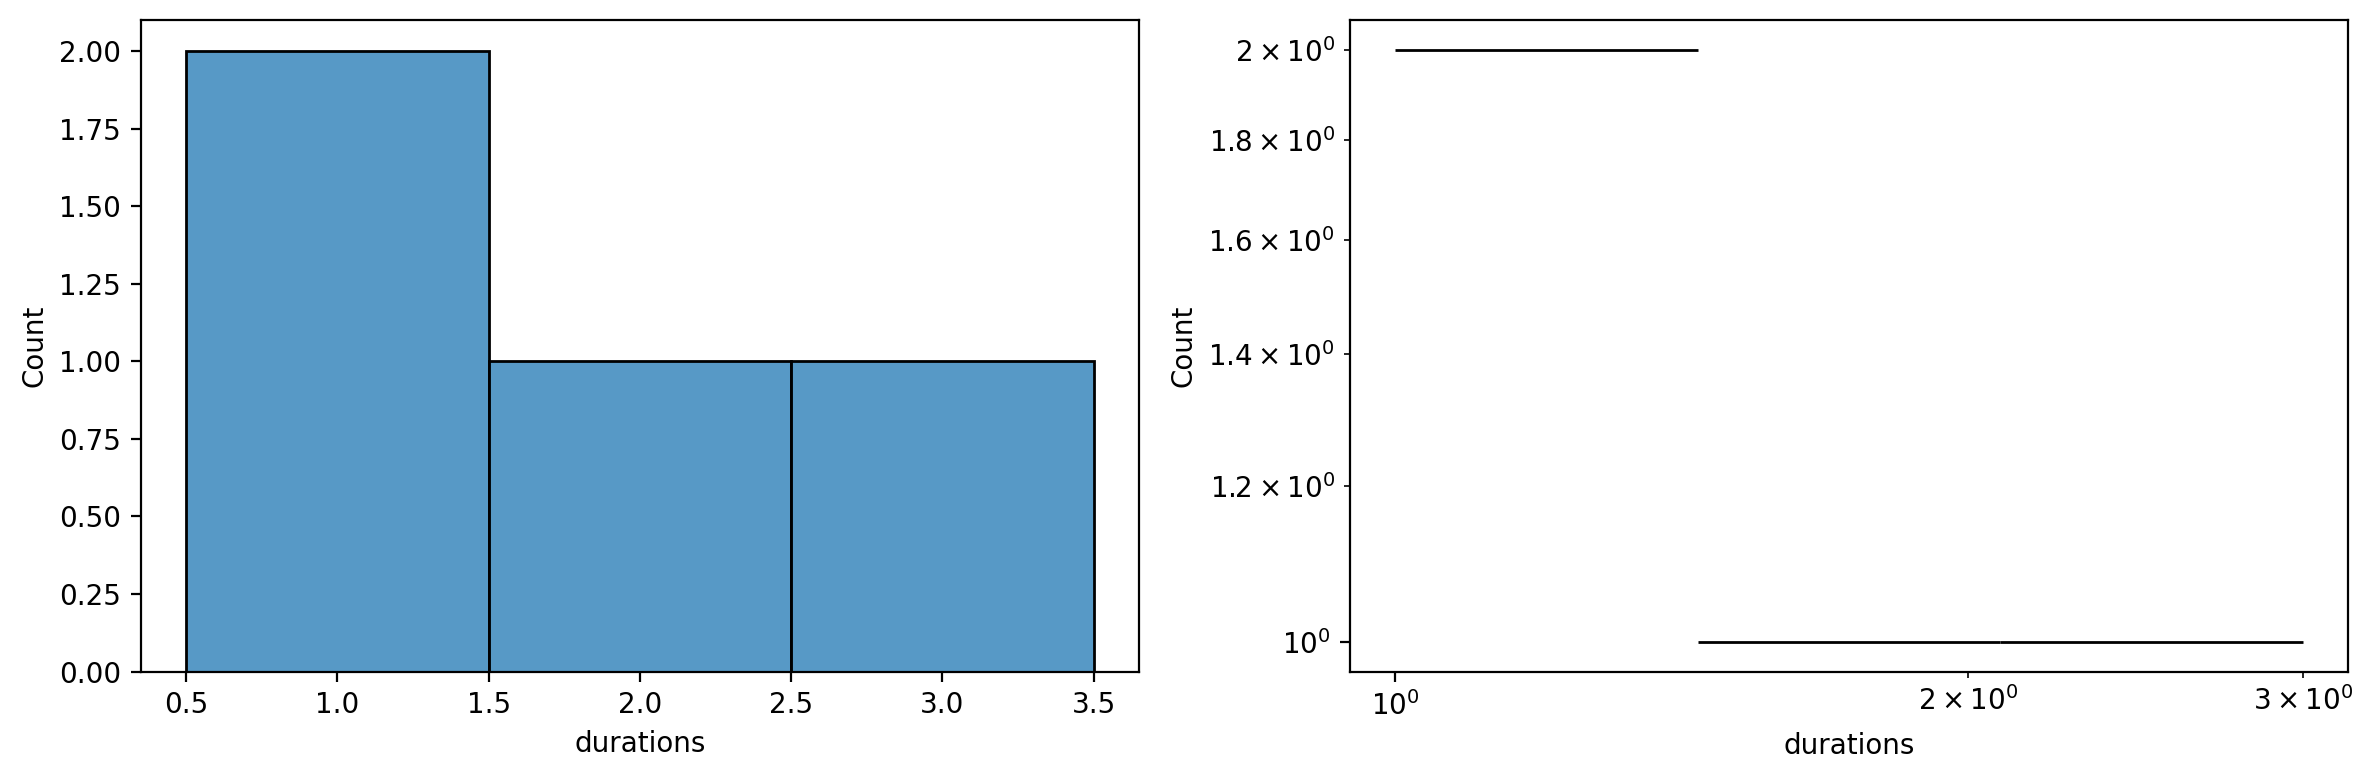

In [22]:
fig, ax=plt.subplots(nrows=1, ncols=2,figsize=(12, 4), dpi=200)
sns.histplot(data=tempo.events_table, x='durations', ax=ax[0], discrete=True)
sns.histplot(data=tempo.events_table, x='durations', ax=ax[1], log_scale=(True, True))
plt.tight_layout()
plt.show()

Above, we show the distributions in both linear and log scale. 


We can also collapse the time dimension entirely, aggregating the temporal network into a static graph. This can be visualized as a heatmap, where each cell's color represents the total weight of edge activations between a pair of nodes.


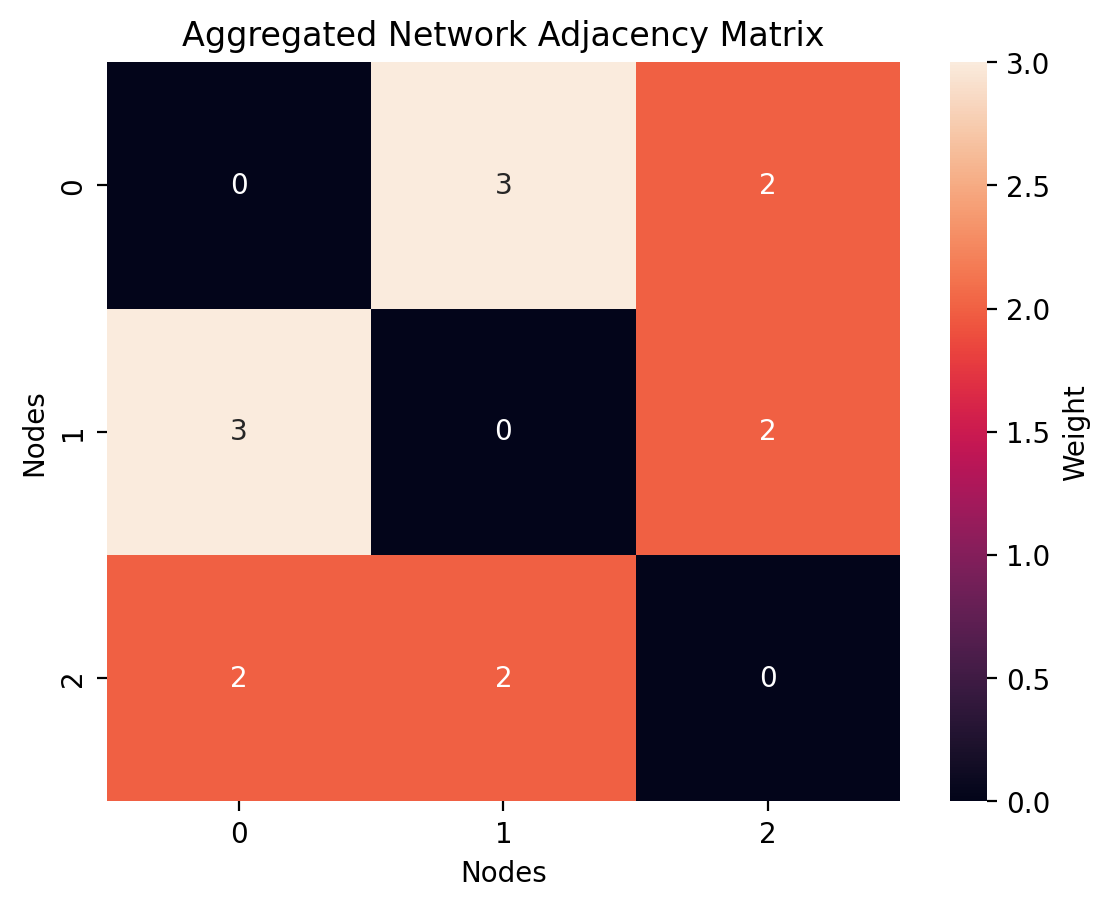

In [160]:
A=tempo.compute_static_adjacency_matrix()

fig, ax=plt.subplots(nrows=1, ncols=1, dpi=200)
sns.heatmap(A.toarray(), ax=ax, annot=True, cbar_kws={'label':'Weight'})
ax.set_xlabel('Nodes')
ax.set_ylabel('Nodes');

ax.set_title('Aggregated Network Adjacency Matrix');

We then transform it to a Networkx object to visualise and perform other algorithms and measure computation. 

In [34]:
static=nx.from_numpy_array(A.toarray())

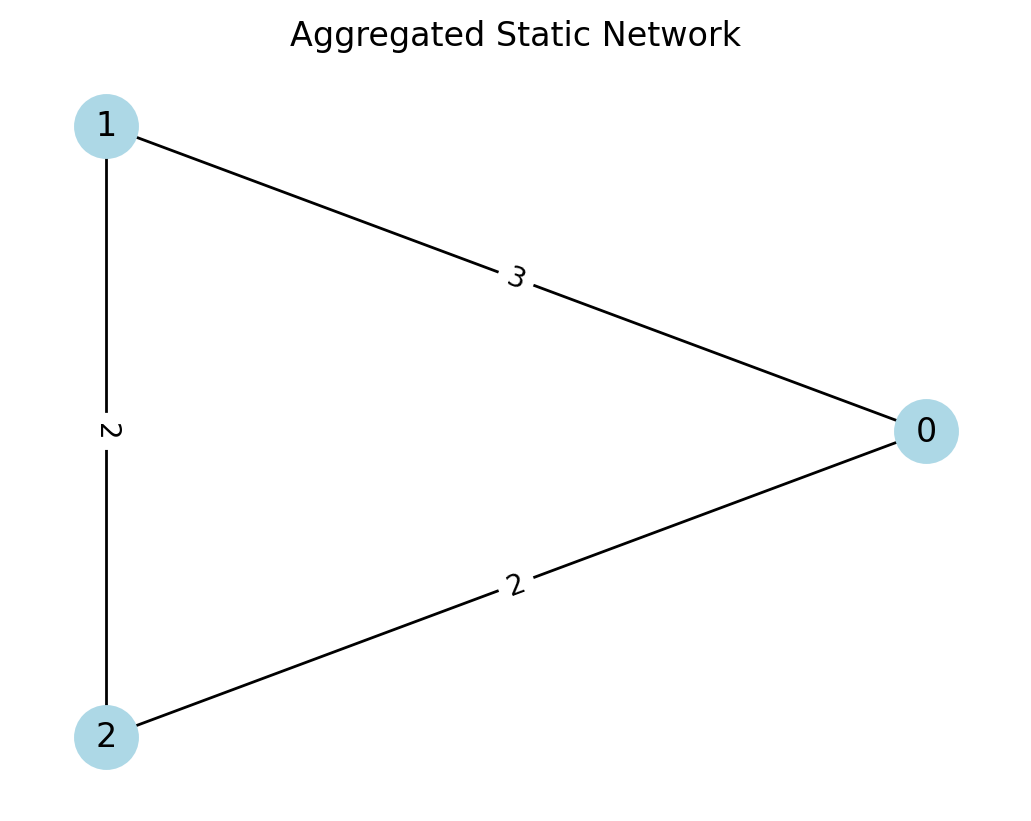

In [39]:
pos = nx.circular_layout(static)

fig, ax=plt.subplots(nrows=1, ncols=1, dpi=200)
nx.draw(static, pos, with_labels=True, node_color="lightblue", node_size=500)
edge_labels = nx.get_edge_attributes(static, "weight")
nx.draw_networkx_edge_labels(static, pos, edge_labels=edge_labels)

plt.title("Aggregated Static Network")
plt.show()

Or if we want to see the network edge weights represented as tickness of the edge, we can do:

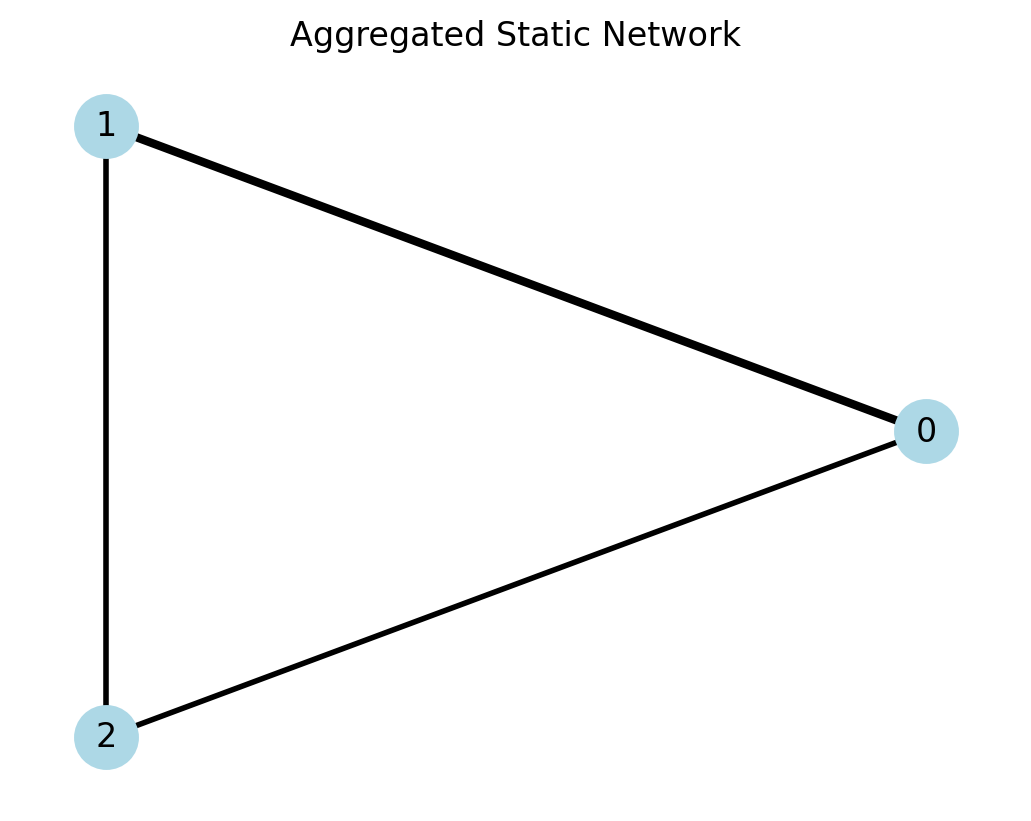

In [84]:
fig, ax=plt.subplots(nrows=1, ncols=1, dpi=200)

weights = [static[u][v]["weight"] for u, v in static.edges()]
max_w = max(weights)
widths = [3 * w / max_w for w in weights] 

nx.draw(static, pos, with_labels=True, width=widths, node_color="lightblue", node_size=500)


plt.title("Aggregated Static Network")
plt.show()

Moving back to temporal network representation, if we want to have access to the list of nodes or all timestamps, we can write: 


In [161]:
print('Node array',tempo.node_array)
print('Timestamps', tempo.times)

Node array [0 1 2]
Timestamps Index([0, 1, 2, 3, 4], dtype='int64', name='times')


To find the start and end of the temporal network, equivalently, the minimum start time and maximum end time, we can query the network directly:


In [43]:
print("Start:", tempo.start_time)
print("End:", tempo.end_time)

Start: 0
End: 4


This package implements the continuous-time random walk on temporal network, which can be used to capture conditional entropy, assortativity, and also community detection like flow stability. Mathematically, given a temporal network with ordered timestamps $t_0, t_1, \dots, t_T$, we construct a sequence of graph snapshots. For each consecutive pair $(t_i, t_{i+1})$, we extract the subgraph of edges active during that interval and compute its **random walk Laplacian**.

For a snapshot with adjacency matrix $A$ and degree matrix $D = \text{diag}(d_1, \dots, d_n)$, the random walk Laplacian is defined as:

$$L_{\text{rw}} = I - D^{-1}A$$

where $I$ is the identity matrix. If a node $i$ has degree $d_i = 0$ in a given snapshot, $D^{-1}$ is undefined. To handle this, we make the random walker stay in place by adding a self-loop to isolated nodes, setting $A_{ii} = 1$ and $d_i = 1$. 

This procedure creates a sequence of Laplacians:

$$L_{\text{rw}}^{(0)},\ L_{\text{rw}}^{(1)},\ \dots,\ L_{\text{rw}}^{(T-1)}$$

one for each time interval $[t_i, t_{i+1})$.


In [85]:
tempo.compute_laplacian_matrices()

2026-05-13 11:14:53,059 - INFO - tempnet\temporal_network.py:1267 - PID:10080 - Computing Laplacians
2026-05-13 11:14:53,084 - INFO - tempnet\temporal_network.py:1326 - PID:10080 - 0 over 4
2026-05-13 11:14:53,086 - INFO - tempnet\temporal_network.py:1330 - PID:10080 - 0.00s
2026-05-13 11:14:53,103 - INFO - tempnet\temporal_network.py:1377 - PID:10080 - Finished in 0.021390676498413086


we can directly access delta laplacian matrices for inspection: 

Text(0.5, 0.98, 'Delta Laplacians')

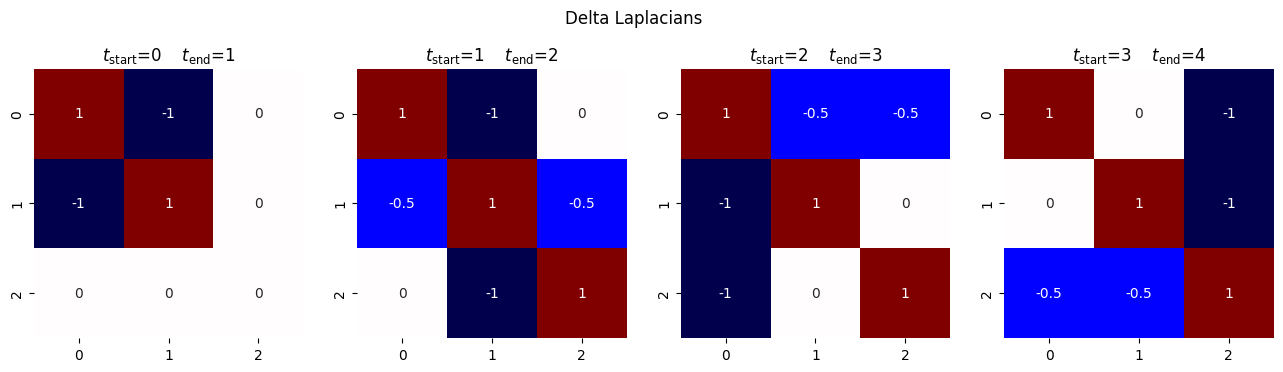

In [157]:
fig, ax=plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
for i in range(4):
    sns.heatmap(tempo.laplacians[i].toarray(), ax=ax[i], square=True, annot=True, cbar=False, vmin=-1, vmax=1, cmap='seismic')
    ax[i].set_title(
        rf'$t_{{\text{{start}}}}$={tempo.times[i]}'
        '\t'
        rf'$t_{{\text{{end}}}}$={tempo.times[i+1]}'
    )
fig.suptitle('Delta Laplacians')

With the random walk Laplacians computed, we simulate the continuous-time random walk by computing the **matrix exponential** of each Laplacian, scaled by the duration of the corresponding time interval and the walker's transition rate.

For two consecutive timestamps $t_i$ and $t_{i+1}$, the transition matrix is:

$$T_{\lambda_{\text{RW}}}^{(i)} = \exp\left(-\lambda_{\text{RW}} \, \Delta t \, L_{\text{rw}}^{(i)}\right)$$

where $\Delta t = t_{i+1} - t_i$ is the duration of the interval and $\lambda_{\text{RW}}$ is the rate of the random walker, controlling how quickly the walker explores the network.

The entry $T_{jk}^{(i)}$ gives the probability that a walker starting at node $j$ at time $t_i$ reaches node $k$ at time $t_{i+1}$.

This produces a sequence of transition matrices:

$$T_{\lambda_{\text{RW}}}^{(0)},\ T_{\lambda_{\text{RW}}}^{(1)},\ \dots,\ T_{\lambda_{\text{RW}}}^{(T-1)}$$

one for each time interval. Each can be computed and visualized directly. 


For example, setting $\lambda_{\text{RW}} = 1$:

```python
tempo.compute_transition_matrices(lambda_rw=1)
```


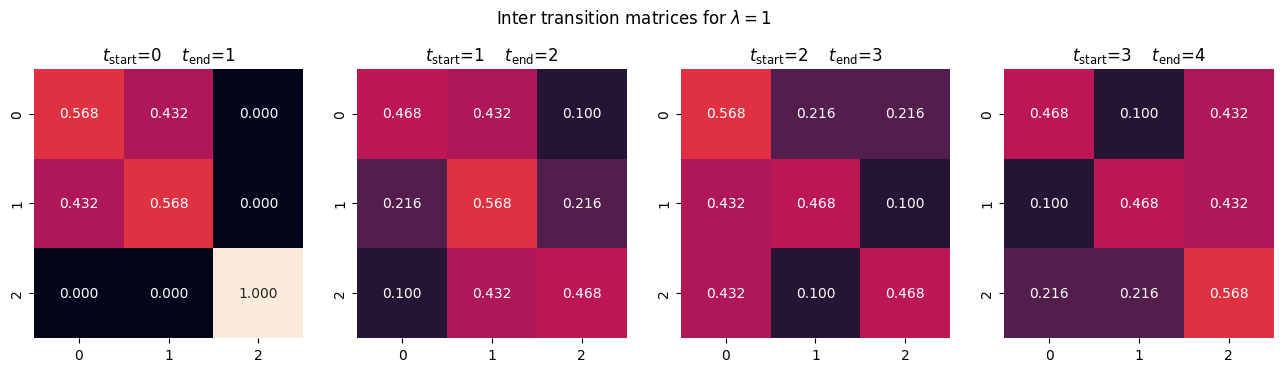

In [164]:
tempo.compute_inter_transition_matrices(lamda=1)
inter_transition_matrices=tempo.inter_T[1]

fig, ax=plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
for i in range(4):
    sns.heatmap(inter_transition_matrices[i].toarray(), ax=ax[i], square=True, annot=True, cbar=False, fmt='.3f', vmin=0, vmax=1)
    ax[i].set_title(
        rf'$t_{{\text{{start}}}}$={tempo.times[i]}'
        '\t'
        rf'$t_{{\text{{end}}}}$={tempo.times[i+1]}'
    )
fig.suptitle('Inter transition matrices for $\lambda=1$');

Now that we have computed all the inter-tranistion matrices, we define the **forward transition matrix** as their product:

$$T_{\lambda_{\text{RW}}} = \prod_{i=0}^{T-1} T_{\lambda_{\text{RW}}}^{(i)}$$

The entry $T_{jk}$ gives the probability that a random walker with rate $\lambda_{\text{RW}}$, starting at node $j$ at the beginning of the network, arrives at node $k$ by the end.

The rate $\lambda_{\text{RW}}$ controls the walker's exploration speed:

- **Low rate** ($\lambda_{\text{RW}} \ll 1$): the walker barely moves, so $T$ remains close to the identity matrix.
- **High rate** ($\lambda_{\text{RW}} \gg 1$): the walker mixes rapidly, washing out temporal structure.

Below, we plot the forward transition matrix for three rates  $\lambda_{\text{RW}} \in \{10^{-2},\ 10^{-1},\ 10\}$.

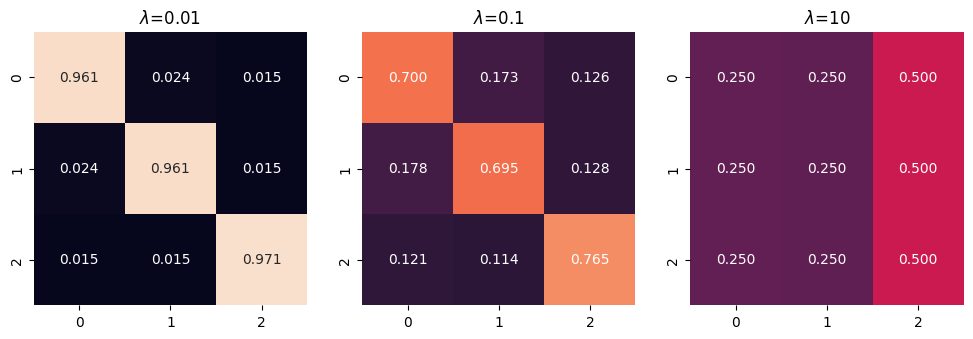

In [153]:
fig, ax=plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for i, lamda in enumerate([1e-2, 0.1, 10]):
    tempo.compute_inter_transition_matrices(lamda=lamda)
    matrix = reduce(lambda a, b: a @ b, tempo.inter_T[lamda])
    sns.heatmap(matrix.toarray(), ax=ax[i], square=True, annot=True, cbar=False, fmt='.3f', vmin=0 , vmax=1)
    ax[i].set_title(rf'$\lambda$={lamda}')
